In [ ]:
Big Question

Can we use different distance metrics with DBSCAN on our telecom customer dataset to discover meaningful customer segments,
and then turn those segments into a business table showing churn risk, upsell opportunity, and cross-sell potential?

In [ ]:
ML Step 1 — Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_distances

In [ ]:
ML Step 2 — Load the dataset

In [3]:
df = pd.read_csv("Telecom.churn")
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
ML Step 3 — Select the business-relevant features

In [4]:
features = [
    'Tenure in Months',
    'Monthly Charge',
    'Total Charges',
    'Contract',
    'Unlimited Data'
]

df_model = df[features].copy()
df_model.head()

,Tenure in Months,Monthly Charge,Total Charges,Contract,Unlimited Data
0,9,65.6,593.30,One Year,Yes
1,9,-4.0,542.40,Month-to-Month,No
2,4,73.9,280.85,Month-to-Month,Yes
3,13,98.0,1237.85,Month-to-Month,Yes
4,3,83.9,267.40,Month-to-Month,Yes


In [ ]:
ML Step 4 — Clean the data

In [5]:
# Remove missing values in selected features
df_model = df_model.dropna().copy()

# Remove negative values in numeric columns if they exist
df_model = df_model[
    (df_model['Tenure in Months'] >= 0) &
    (df_model['Monthly Charge'] >= 0) &
    (df_model['Total Charges'] >= 0)
].copy()

df_model.shape

(5423, 5)

In [ ]:
ML Step 5 — Encode categorical features

In [7]:
df_encoded = pd.get_dummies(df_model, columns=['Contract', 'Unlimited Data'], drop_first=False)
df_encoded=df_encoded.astype(int)
df_encoded.head()

,Tenure in Months,Monthly Charge,Total Charges,Contract_Month-to-Month,Contract_One Year,Contract_Two Year,Unlimited Data_No,Unlimited Data_Yes
0,9,65,593,0,1,0,0,1
2,4,73,280,1,0,0,0,1
3,13,98,1237,1,0,0,0,1
4,3,83,267,1,0,0,0,1
5,9,69,571,1,0,0,0,1


In [8]:
print(df_encoded.shape)

(5423, 8)


In [ ]:
ML Step 6 — Standardize the data

In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)

scaled_data[:5]

array([[-0.97415135, -0.52063232, -0.90776393, -1.12862507,  1.91492912,
        -0.53962068, -0.40309627,  0.40309627],
       [-1.17758252, -0.15587693, -1.04055514,  0.88603384, -0.52221254,
        -0.53962068, -0.40309627,  0.40309627],
       [-0.81140641,  0.98398366, -0.63454494,  0.88603384, -0.52221254,
        -0.53962068, -0.40309627,  0.40309627],
       [-1.21826875,  0.3000673 , -1.04607043,  0.88603384, -0.52221254,
        -0.53962068, -0.40309627,  0.40309627],
       [-0.97415135, -0.33825463, -0.91709749,  0.88603384, -0.52221254,
        -0.53962068, -0.40309627,  0.40309627]])

In [ ]:
ML Step 7 — Inspect average pairwise distances

In [10]:
euclidean_mean = euclidean_distances(scaled_data).mean()
manhattan_mean = manhattan_distances(scaled_data).mean()
cosine_mean = cosine_distances(scaled_data).mean()

print("Average Euclidean distance:", round(euclidean_mean, 2))
print("Average Manhattan distance:", round(manhattan_mean, 2))
print("Average Cosine distance:", round(cosine_mean, 2))

Average Euclidean distance: 3.67
Average Manhattan distance: 7.44
Average Cosine distance: 0.98


In [ ]:
ML Step 8 — Run DBSCAN with tuned eps for each metric

In [11]:
db_euclidean = DBSCAN(eps=0.4, min_samples=5, metric='euclidean')
labels_euclidean = db_euclidean.fit_predict(scaled_data)

db_manhattan = DBSCAN(eps=0.9, min_samples=5, metric='manhattan')
labels_manhattan = db_manhattan.fit_predict(scaled_data)

db_cosine = DBSCAN(eps=0.98, min_samples=5, metric='cosine')
labels_cosine = db_cosine.fit_predict(scaled_data)

In [ ]:
ML Step 9 — Count clusters for each metric( Capturing Noise ) in each cluster 

In [12]:
def count_clusters(labels):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    return n_clusters, n_noise

print("Euclidean:", count_clusters(labels_euclidean))
print("Manhattan:", count_clusters(labels_manhattan))
print("Cosine:", count_clusters(labels_cosine))

Euclidean: (7, 65)
Manhattan: (7, 16)
Cosine: (1, 0)


In [ ]:
ML Step 10 — Inspect noise and cluster sizes

In [13]:
np.unique(labels_euclidean, return_counts=True)

(array([-1,  0,  1,  2,  3,  4,  5,  6]),
 array([  65,  992, 2600, 1067,  122,  147,  425,    5]))

In [ ]:
ML Step 11 — Attach cluster labels to the original dataset

In [14]:
df_business = df.loc[df_model.index].copy()
df_business['cluster'] = labels_euclidean

df_business.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,cluster
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,65.6,593.30,0.0,0,381.51,974.81,Stayed,NaN,NaN,0
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,73.9,280.85,0.0,0,134.60,415.45,Churned,Competitor,Competitor had better devices,1
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,98.0,1237.85,0.0,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,1
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,83.9,267.40,0.0,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,1
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,...,69.4,571.45,0.0,0,150.93,722.38,Stayed,NaN,NaN,1


In [ ]:
ML Step 12 — Remove DBSCAN noise

In [15]:
df_business = df_business[df_business['cluster'] != -1].copy()

In [ ]:
ML Step 13 — Remove tiny clusters

In [16]:
cluster_counts = df_business['cluster'].value_counts()
valid_clusters = cluster_counts[cluster_counts > 50].index

df_business = df_business[df_business['cluster'].isin(valid_clusters)].copy()
df_business['cluster'].value_counts()

cluster
1    2600
2    1067
0     992
5     425
4     147
3     122
Name: count, dtype: int64

In [ ]:
ML Step 14 — Create churn flag

In [17]:
print(df_business['Customer Status'].value_counts())

Customer Status
Stayed     3367
Churned    1723
Joined      263
Name: count, dtype: int64


In [18]:
df_business['churn_flag'] = (df_business['Customer Status'] == 'Churned').astype(int)

In [ ]:
ML Step 15 — Build the business table

In [19]:
business_table = df_business.groupby('cluster').agg(
    customers=('cluster', 'size'),
    avg_monthly_charge=('Monthly Charge', 'mean'),
    avg_tenure=('Tenure in Months', 'mean'),
    avg_total_charges=('Total Charges', 'mean'),
    churn_rate=('churn_flag', 'mean'),
    month_to_month_pct=('Contract', lambda x: (x == 'Month-to-month').mean()),
    unlimited_data_pct=('Unlimited Data', lambda x: (x == 'Yes').mean())
).reset_index()

In [ ]:
ML Step 16 — Format the business table

In [20]:
business_table['avg_monthly_charge'] = business_table['avg_monthly_charge'].round(2)
business_table['avg_tenure'] = business_table['avg_tenure'].round(1)
business_table['avg_total_charges'] = business_table['avg_total_charges'].round(2)

business_table['churn_rate'] = (business_table['churn_rate'] * 100).round(1)
business_table['month_to_month_pct'] = (business_table['month_to_month_pct'] * 100).round(1)
business_table['unlimited_data_pct'] = (business_table['unlimited_data_pct'] * 100).round(1)

In [ ]:
ML Step 17 — Add churn risk level

In [21]:
def churn_risk_label(rate):
    if rate >= 50:
        return 'High Risk'
    elif rate >= 25:
        return 'Medium Risk'
    else:
        return 'Low Risk'

business_table['churn_risk_level'] = business_table['churn_rate'].apply(churn_risk_label)

In [ ]:
ML Step 18 — Add recommended business action

In [22]:
def business_action(row):
    if row['churn_rate'] >= 50 and row['avg_tenure'] < 24:
        return 'Urgent retention offer'
    elif row['churn_rate'] >= 25 and row['avg_monthly_charge'] >= 70:
        return 'Retention + price review'
    elif row['churn_rate'] < 25 and row['avg_tenure'] >= 40 and row['avg_monthly_charge'] >= 70:
        return 'Upsell premium services'
    elif row['churn_rate'] < 25 and row['unlimited_data_pct'] < 50:
        return 'Cross-sell unlimited data'
    else:
        return 'Monitor and nurture'

business_table['recommended_action'] = business_table.apply(business_action, axis=1)

In [ ]:
ML Step 19 — Final sorted business table

In [23]:
business_table = business_table.sort_values(by='churn_rate', ascending=False)
business_table

,cluster,customers,avg_monthly_charge,avg_tenure,avg_total_charges,churn_rate,month_to_month_pct,unlimited_data_pct,churn_risk_level,recommended_action
5,5,425,72.77,18.5,1467.99,50.6,0.0,0.0,High Risk,Urgent retention offer
1,1,2600,73.30,18.6,1480.16,50.4,0.0,100.0,High Risk,Urgent retention offer
4,4,147,82.39,46.9,3984.02,15.6,0.0,0.0,Low Risk,Upsell premium services
0,0,992,79.69,45.1,3753.46,13.2,0.0,100.0,Low Risk,Upsell premium services
3,3,122,87.50,66.1,5815.10,4.9,0.0,0.0,Low Risk,Upsell premium services
2,2,1067,83.65,56.7,4871.74,3.5,0.0,100.0,Low Risk,Upsell premium services


In [ ]:
BAR CHART — CHURN RATE PER CLUSTER (MOST IMPORTANT)

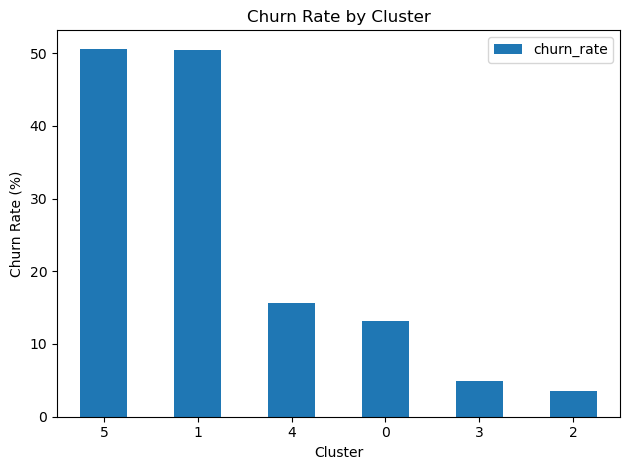

In [24]:
import matplotlib.pyplot as plt

business_table.sort_values('churn_rate', ascending=False).plot(
    x='cluster', y='churn_rate', kind='bar'
)

plt.title("Churn Rate by Cluster")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
2. CLUSTER SIZE (WHERE THE MONEY IS)

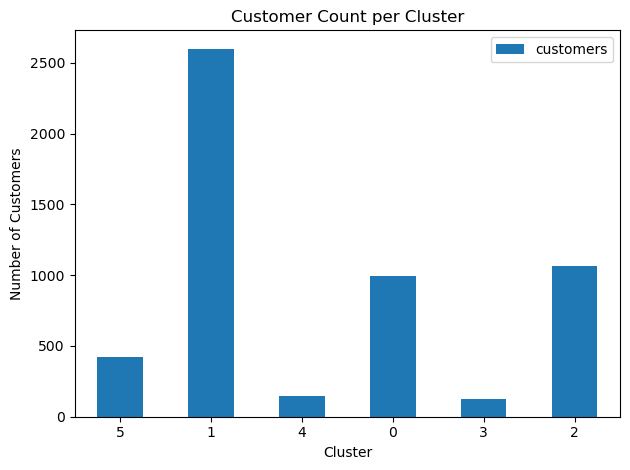

In [25]:
business_table.plot(
    x='cluster', y='customers', kind='bar'
)

plt.title("Customer Count per Cluster")
plt.ylabel("Number of Customers")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
🔥 3. SCATTER — TENURE vs MONTHLY CHARGE (REAL SEGMENT VIEW)

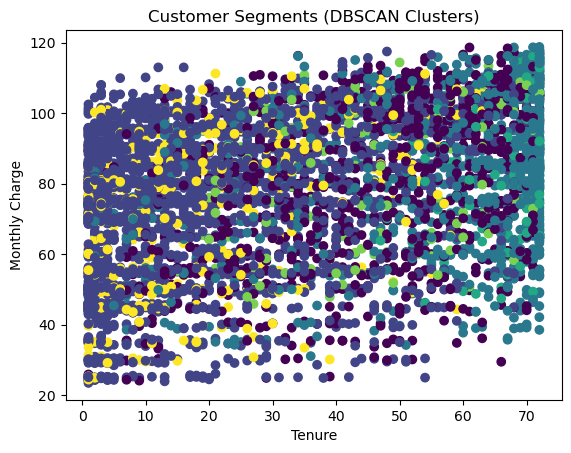

In [28]:
plt.scatter(
    df_business['Tenure in Months'],
    df_business['Monthly Charge'],
    c=df_business['cluster']
)

plt.xlabel("Tenure")
plt.ylabel("Monthly Charge")
plt.title("Customer Segments (DBSCAN Clusters)")
plt.show()

In [ ]:
🔥 4. HEATMAP — FULL BUSINESS TABLE (POWER VIEW)

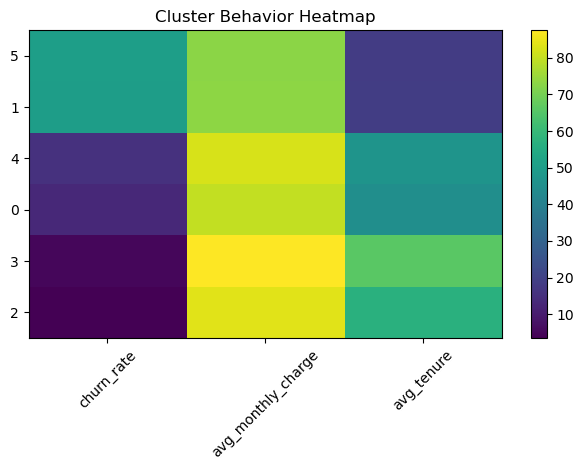

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

heatmap_data = business_table.set_index('cluster')[
    ['churn_rate', 'avg_monthly_charge', 'avg_tenure']
]

plt.imshow(heatmap_data, aspect='auto')
plt.colorbar()

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.title("Cluster Behavior Heatmap")
plt.tight_layout()
plt.show()